<a href="https://colab.research.google.com/github/sevaradevoloper/mldanishla/blob/main/GradientBoosting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opendatasets
!pip install legacy-cgi opendatasets --upgrade

In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/srisyra02/online-food-ordering-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sevaradev
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/srisyra02/online-food-ordering-dataset


100%|██████████| 3.56k/3.56k [00:00<00:00, 7.00MB/s]

In [ ]:
import pandas as pd
df = pd.read_csv("/content/online-food-ordering-dataset/online food delivery dataset.csv")
# df.info()
df.isnull().sum()
df = df.drop(columns=['Unnamed: 13', 'Pin code', 'latitude', 'longitude'],errors='ignore')
# df.info()

# encoding
# # from sklearn.preprocessing import OneHotEncoder
df["Output"] = df["Output"].map({'Yes':1,'No':0})
df = pd.get_dummies(df,drop_first=True,dtype=int)
# df.info()

# train va test
from sklearn.model_selection import train_test_split
X = df.drop(columns=["Output"])
y = df["Output"]

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit emas, transform!

# Model
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train_scaled, y_train)

# Predict (Test ma'lumotida bashorat qilamiz!)
y_pred = model.predict(X_test_scaled)  # X_train_scaled emas!

# Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8974

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.71      0.75        17
           1       0.92      0.95      0.94        61

    accuracy                           0.90        78
   macro avg       0.86      0.83      0.84        78
weighted avg       0.89      0.90      0.90        78



In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier()
rf_model.fit(X_train_scaled,y_train)
y_pred_rf = rf_model.predict(X_test_scaled)
from sklearn.metrics import accuracy_score, precision_score, recall_score

def evaluate_model(model_name,y_true,y_pred):
    return {
          'Model':model_name,
          'Accuracy': accuracy_score(y_true, y_pred),
          'Precision': precision_score(y_true, y_pred),
          'Recall': recall_score(y_true, y_pred),
      }
gb_results = evaluate_model("GradientBoosting",y_test,y_pred)
rf_results = evaluate_model("RandomForest",y_test,y_pred_rf)

df_camp = pd.DataFrame([gb_results,rf_results])
print(df_camp)

              Model  Accuracy  Precision    Recall
0  GradientBoosting  0.897436   0.920635  0.950820
1      RandomForest  0.897436   0.934426  0.934426


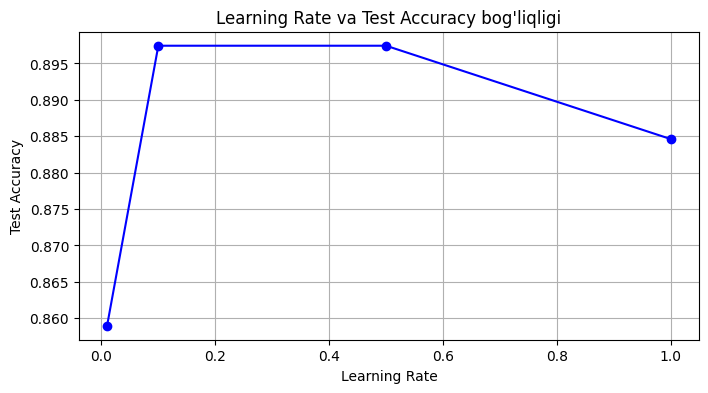

In [ ]:

import matplotlib.pyplot as plt

learning_rates = [0.01, 0.1, 0.5, 1.0]
test_accuracies = []

for lr in learning_rates:
    gb = GradientBoostingClassifier(learning_rate=lr, random_state=42)
    gb.fit(X_train_scaled, y_train)
    gb_pred = gb.predict(X_test_scaled)
    gb_acc = accuracy_score(y_test, gb_pred)
    test_accuracies.append(gb_acc)

plt.figure(figsize=(8, 4))
plt.plot(learning_rates, test_accuracies, marker='o', color='blue')
plt.title('Learning Rate va Test Accuracy bog\'liqligi')
plt.xlabel('Learning Rate')
plt.ylabel('Test Accuracy')
plt.grid()
plt.show()

In [ ]:
# Grafikdan ko'rinib turgan natijalarga ko'ra xulosa quyidagicha:
# Optimal nuqta (learning_rate=0.1):
# Aynan 0.1 qiymatda test ma'lumotlaridagi aniqlik (Accuracy) eng yuqori darajaga (~0.897) erishgan. Bu standart va eng optimal qiymat hisoblanadi.
# Underfitting (learning_rate=0.01):
# Qadam o'lchami juda kichik bo mezoniy bo'lgani uchun model berilgan daraxtlar sonida yetarlicha o'rganishga ulgurmagan va aniqlik eng past (~0.859) bo'lib qolgan.
# Overfitting / Shoshqaloqlik (learning_rate=0.5 va 1.0):
# Qadam o'lchami juda katta bo'lganda model optimal yechimdan o'tib ketadi va xatoliklar ustida xatolik ko'payib, test aniqligi tushib ketadi (learning_rate=1.0 da ~0.885 ga tushgan).

In [ ]:
# orta daraja
gb1 = GradientBoostingClassifier(learning_rate=0.01,n_estimators=500,random_state=42)
gb2 = GradientBoostingClassifier(learning_rate=0.5,n_estimators=20,random_state=42)
gb1.fit(X_train_scaled,y_train)
gb2.fit(X_train_scaled,y_train)

gb1_pred_train = gb1.predict(X_train_scaled)
gb1_pred_test = gb1.predict(X_test_scaled)

gb2_pred_train = gb2.predict(X_train_scaled)
gb2_pred_test = gb2.predict(X_test_scaled)

gb1_acc_train = accuracy_score(y_train,gb1_pred_train)
gb1_acc_test = accuracy_score(y_test,gb1_pred_test)

gb2_acc_train = accuracy_score(y_train, gb2_pred_train)
gb2_acc_test = accuracy_score(y_test,gb2_pred_test)
print("Model 1 Train:", gb1_acc_train, "Test:", gb1_acc_test)
print("Model 2 Train:", gb2_acc_train, "Test:", gb2_acc_test)

Model 1 Train: 0.9225806451612903 Test: 0.8717948717948718
Model 2 Train: 0.9483870967741935 Test: 0.8717948717948718


In [ ]:
# qiyin

In [ ]:
import time
start_gb = time.time()
gb.fit(X_train_scaled,y_train)
end_gb = time.time()
gb_time = end_gb - start_gb

gb_pred = gb.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, gb_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, gb_pred))

print("----" *20)

start_rf = time.time()
rf_model.fit(X_train_scaled,y_train)
end_rf = time.time()
rf_time = end_rf - start_rf

rf_pred = rf_model.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, rf_pred):.4f}\n")
print("Classification Report:\n", classification_report(y_test, rf_pred))

def hammasibitada(model_name, time_taken, y_true, y_pred):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "Time (s)": time_taken
    }

gb_results_time = hammasibitada("GradientBoostingClassifier",gb_time,y_test,gb_pred)
rf_results_time = hammasibitada("RandomForestClassifier",rf_time,y_test,rf_pred)

df_bita = pd.DataFrame([gb_results_time,rf_results_time])
print(df_bita)

Accuracy: 0.8846

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.71      0.73        17
           1       0.92      0.93      0.93        61

    accuracy                           0.88        78
   macro avg       0.83      0.82      0.83        78
weighted avg       0.88      0.88      0.88        78

--------------------------------------------------------------------------------
Accuracy: 0.9103

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.76      0.79        17
           1       0.94      0.95      0.94        61

    accuracy                           0.91        78
   macro avg       0.87      0.86      0.87        78
weighted avg       0.91      0.91      0.91        78

                        Model  Accuracy  Precision    Recall  Time (s)
0  GradientBoostingClassifier  0.884615   0.919355  0.934426  0.214123
1      RandomForestClassifier  0.910256

In [ ]:
# hulosa:smonli (default) parametrlar berilganda Random Forest
# modeli test ma'lumotlarida yuqoriroq aniqlik ko'rsatdi(Accuracy: 91.0% vs 88.5%).
# Biroq, o'qitish tezligi bo'yicha Gradient Boosting biroz tezroq (0.21s vs 0.28s) natija berdi.
# Kichik datasetlarda Random Forest tezda yaxshi natija berishi mumkin,
#  ammo Gradient Boosting hyperparameter tuning qilinganda aniqlikni yanada oshirish imkoniyatiga ega.